# Commande PID d'un double intégrateur


Le but de ce notebook est de caluler et de simuler un controleur RST agissant sur un modèle d'une balle sur poutre  

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

Configuration de la simulation:


T est le temps total de simulation et dt est le temps d'échantillonage du correcteur

In [11]:
ballbeam_config.T=6
ballbeam_config.dt=0.05

In [12]:
X_0=np.array([[0],[0]]) ## état initial attention la syntaxe
double_int=TransferFunctionModel(ballbeam_config) ## instance de TransferFunctionModel
Double_int_sim=TFSimulator(double_int.Tf_dis,X_0) ## Double_int_sim est le simulateur de fonctions de transfert discrètes 
A=double_int.Tf_dis.den_list[0][0] ## extraction du numérateur, attention la syntaxe
B=double_int.Tf_dis.num_list[0][0] ## extraction du dénominateur 


In [13]:
### affichage 
print(double_int.Tf_cont)
print(double_int.Tf_dis)

<TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
<TransferFunction>: sys[20]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z + 0.0002625
  -----------------------
       z^2 - 2 z + 1


Déptermination des gains du PID

In [50]:
kp=280
ki=0
kd=95

Synthèse du correcteur PID:
Ici, nous ajoutons un filtre de l'action dérivée avec le mot-clé "filtered"

In [51]:
PID_controller=DiscretePID(kp,ki,kd,ballbeam_config.dt,"filtered")

In [52]:
L = PID_controller.transferFunction * double_int.Tf_dis
T = ct.feedback(L, 1)
print(T)
print("DC gain:",T.dcgain())

<TransferFunction>: sys[140]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

      1.504 z^2 + 0.1837 z - 1.32
  ------------------------------------
  3.5 z^3 - 6.496 z^2 + 5.684 z - 2.32
DC gain: 0.9999999999999988


### Simulation
On utilise le simulateur discret. Le premier True/False détermine la présence d'une perturbation constante au bout de la troisième seconde. Le deuxième active (si True) la saturation de l'actionneur.

In [53]:
logger_PID = SimLog()

reference=1.0
y_0=0.0

logger_PID= run_discrete_control(Double_int_sim,PID_controller,ballbeam_config,reference,y_0,logger_PID,True,True)
#logger_rst= run_discrete_control(Double_int_sim,PID_controller,ballbeam_config,reference,y_0,logger_rst,False,False)

Création de la fonction de transfert perturbation/sortie $Gd=\frac{BS}{AS+BR}$ et simulation de sa réponse inditielle

In [54]:
Gd = ct.minreal(double_int.Tf_dis / (1 + PID_controller.transferFunction*double_int.Tf_dis))

print(Gd)
print("dcgain:", ct.dcgain(Gd))

t = np.arange( 0,ballbeam_config.T,ballbeam_config.dt)
t = np.asarray(t).flatten()

_, d = ct.step_response(Gd,t)



2 states have been removed from the model
<TransferFunction>: sys[145]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z^2 + 0.0001875 z - 7.5e-05
  -------------------------------------
    z^3 - 1.856 z^2 + 1.624 z - 0.663
dcgain: 0.0035714285714232934


Affichage des trois réponses

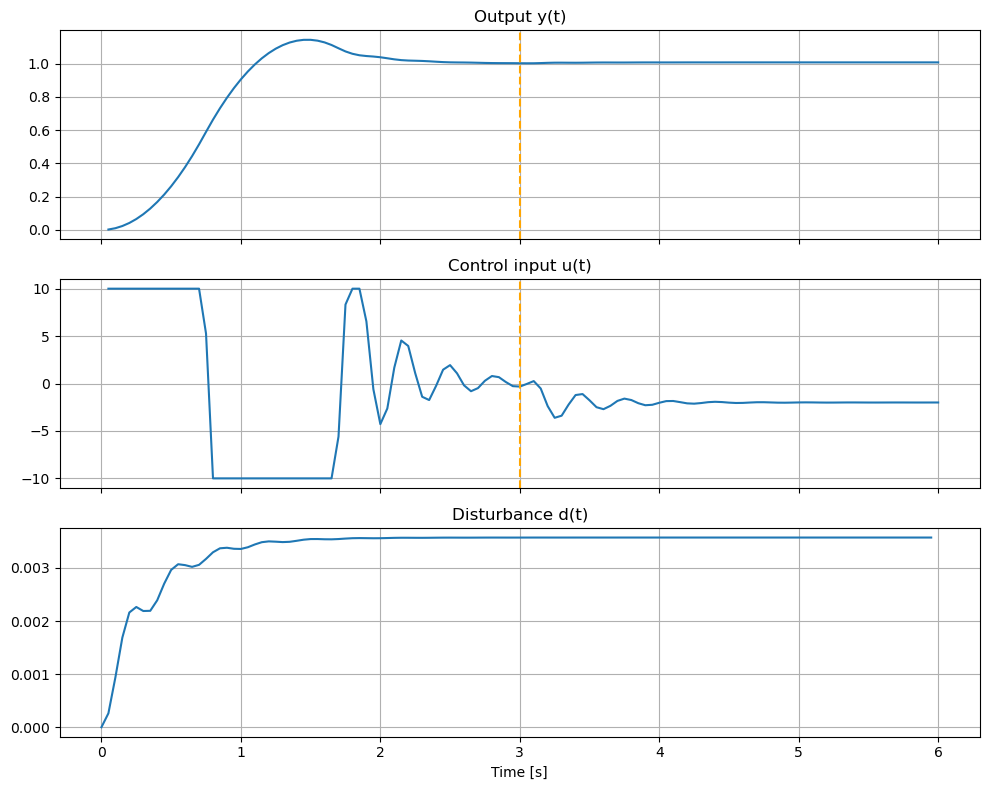

In [55]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(logger_PID.t_hist, logger_PID.y_hist)
ax[0].set_title("Output y(t)")
ax[0].grid()


ax[1].plot(logger_PID.t_hist, logger_PID.u_hist)
ax[1].set_title("Control input u(t)")
ax[1].grid()

ax[1].legend


ax[2].plot(t, d)
ax[2].set_title("Disturbance d(t)")
ax[2].grid()

ax[0].axvline(x=3, color='orange', linestyle='--',label='Disturbance')
ax[1].axvline(x=3, color='orange', linestyle='--',label='Disturbance')
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()